# WA EVs: Lasso and Ridge (L1 and L2 Regularization)

### Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Load Data

In [13]:
import os
os.chdir(r"C:\Users\alexm\Documents\GitHub\SML_group_project")
print("Working directory:", os.getcwd())

df = pd.read_csv('data/county_scaled.csv')
print('county_scaled shape:', df.shape)
display(df.head(5))

Working directory: C:\Users\alexm\Documents\GitHub\SML_group_project
county_scaled shape: (39, 25)


,county,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,total_chargers,level1_chargers,level2_chargers,dc_fast_chargers,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146,0.167054,-0.164494,-0.056726,-0.943417,-0.284265,-0.185346,-0.283009,-0.281631,2.701390,1.016734,-1.114216,-1.056557,-1.189832,-0.650199,-0.354030,-1.817486,0.251486,1.534355
1,ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187,-0.587885,0.589688,-0.825894,-0.531097,-0.302321,-0.185346,-0.277127,-0.463012,-0.849210,-0.369807,-1.047830,-1.038530,-1.017391,-1.403685,-0.354030,-1.146074,-1.099162,-0.357901
2,BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907,-0.033466,0.035825,-0.291918,0.769852,-0.191406,-0.185346,-0.194781,-0.160711,0.334323,-0.468077,0.649723,0.626235,0.710560,0.304856,-0.354030,0.281179,0.527180,-0.688372
3,CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473,1.161181,-1.157625,1.672837,0.035469,-0.101126,0.283529,-0.127139,0.081131,0.349117,0.243146,0.249647,0.307819,0.080535,0.658957,2.363072,0.620363,0.855439,0.797796
4,CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965,-0.215862,0.218038,-0.484569,-0.368438,-0.132080,-0.185346,-0.150667,0.000517,0.351728,0.056492,0.277632,0.257791,0.340796,0.558610,-0.354030,0.522370,0.765017,0.537893


### Data Preparation

In [14]:
# Keep only numeric columns.
numeric_df = df.select_dtypes(include=[np.number]).copy()

target_col = "total_EV_count"

# Use all numeric columns except target as predictors.
X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

# Remove log-transformed columns
X = X.drop(columns=[c for c in X.columns if c.endswith("_log")])

### Train/Test Split (75/25)

In [15]:
# 75/25 split with fixed random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print("Data Split Shapes")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Data Split Shapes
X_train: (29, 15)
X_test : (10, 15)
y_train: (29,)
y_test : (10,)


## Ridge & Lasso with Alpha Grid

### Shared Alpha Grid

In [16]:
alpha_grid = np.logspace(-4, 4, 100)

### Ridge with Cross Validation

In [17]:
ridge_model = RidgeCV(alphas=alpha_grid, cv=5)
ridge_model.fit(X_train, y_train)
print(f"\nBest alpha (Ridge): {ridge_model.alpha_:.6f}")


Best alpha (Ridge): 0.000100


### Lasso  with Cross Validation

In [18]:
lasso_model = LassoCV(alphas=alpha_grid, cv=5, random_state=0, max_iter=10**4)
lasso_model.fit(X_train, y_train)
print(f"Best alpha (Lasso): {lasso_model.alpha_:.6f}")

Best alpha (Lasso): 0.000175


### Evaluation 1: Compute Metrics for Both Models

In [19]:
# Evaluation metrics
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    return {
        "Train RMSE": mean_squared_error(y_tr, y_tr_pred) ** 0.5,
        "Test RMSE": mean_squared_error(y_te, y_te_pred) ** 0.5,
        "Train MAE": mean_absolute_error(y_tr, y_tr_pred),
        "Test MAE": mean_absolute_error(y_te, y_te_pred),
        "Train R^2": r2_score(y_tr, y_tr_pred),
        "Test R^2": r2_score(y_te, y_te_pred),
    }


ridge_metrics = evaluate_model(ridge_model, X_train, y_train, X_test, y_test)
lasso_metrics = evaluate_model(lasso_model, X_train, y_train, X_test, y_test)

results_df = pd.DataFrame([ridge_metrics, lasso_metrics], index=["Ridge", "Lasso"])

print("\nModel Performance")
print(results_df.round(4).to_string())


Model Performance
       Train RMSE  Test RMSE  Train MAE  Test MAE  Train R^2  Test R^2
Ridge      0.0000     0.0001     0.0000    0.0001        1.0    1.0000
Lasso      0.0013     0.0010     0.0008    0.0009        1.0    0.9999


### Evaluation 2: Coefficient Magnitude Plots

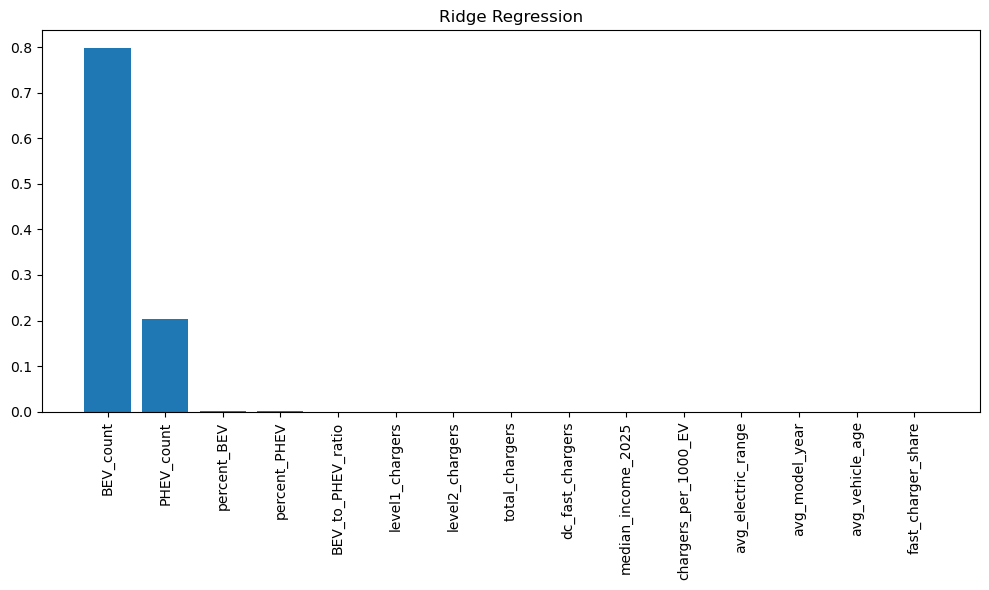

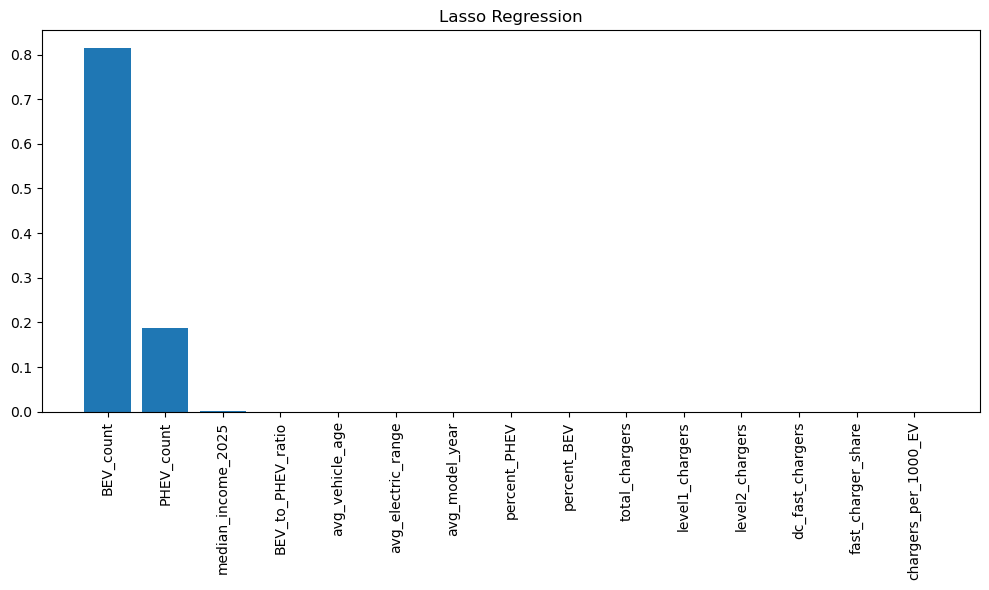

In [20]:
# Plot coefficient magnitude plots
def plot_sorted_coefficient_magnitudes(coefficients, feature_names, title):
    coef_mag = pd.Series(np.abs(coefficients), index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(10,6))
    plt.bar(range(len(coef_mag)), coef_mag.values)
    plt.xticks(range(len(coef_mag)), coef_mag.index, rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_sorted_coefficient_magnitudes(ridge_model.coef_, X.columns, "Ridge Regression")
plot_sorted_coefficient_magnitudes(lasso_model.coef_, X.columns, "Lasso Regression")

### Quick Summary of the Results

In [21]:
# Best alpha values
print(f"Best alpha (Ridge): {ridge_model.alpha_:.6f}")
print(f"Best alpha (Lasso): {lasso_model.alpha_:.6f}")

# Metrics
print("\nMetrics:")
print(results_df.round(4))

# Number of nonzero coefficients in Lasso
lasso_nonzero = np.sum(lasso_model.coef_ != 0)
print("\nLasso nonzero coefficients:", lasso_nonzero)

# Top features
top_lasso = pd.Series(lasso_model.coef_, index=X.columns).abs().sort_values(ascending=False).head(10)
top_ridge = pd.Series(ridge_model.coef_, index=X.columns).abs().sort_values(ascending=False).head(10)
print("\nTop Lasso features:\n" + top_lasso.to_string())
print("\nTop Ridge features:\n" + top_ridge.to_string())

Best alpha (Ridge): 0.000100
Best alpha (Lasso): 0.000175

Metrics:
       Train RMSE  Test RMSE  Train MAE  Test MAE  Train R^2  Test R^2
Ridge      0.0000     0.0001     0.0000    0.0001        1.0    1.0000
Lasso      0.0013     0.0010     0.0008    0.0009        1.0    0.9999

Lasso nonzero coefficients: 4

Top Lasso features:
BEV_count             0.813577
PHEV_count            0.186346
median_income_2025    0.001010
BEV_to_PHEV_ratio     0.000203
avg_vehicle_age       0.000000
avg_electric_range    0.000000
avg_model_year        0.000000
percent_PHEV          0.000000
percent_BEV           0.000000
total_chargers        0.000000

Top Ridge features:
BEV_count             0.796894
PHEV_count            0.203571
percent_BEV           0.002135
percent_PHEV          0.002022
BEV_to_PHEV_ratio     0.000124
level1_chargers       0.000044
level2_chargers       0.000042
total_chargers        0.000041
dc_fast_chargers      0.000028
median_income_2025    0.000019


### Does Lasso always pick BEV_count and PHEV_count?

In [22]:
from sklearn.model_selection import RepeatedKFold
from collections import Counter

rk = RepeatedKFold(n_splits=5, n_repeats=20, random_state=0)

selection_counts = Counter()
rmse_list = []

for train_idx, test_idx in rk.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Tune alpha inside each fold
    lasso_cv = LassoCV(alphas=alpha_grid, cv=5, random_state=0, max_iter=10**4)
    lasso_cv.fit(X_tr, y_tr)

    # Predictions
    y_pred = lasso_cv.predict(X_te)
    rmse_list.append(mean_squared_error(y_te, y_pred) ** 0.5)

    # Track selected features
    selected = X.columns[lasso_cv.coef_ != 0]
    selection_counts.update(selected)

# Convert to frequency table
selection_freq = pd.Series(selection_counts).sort_values(ascending=False)

print("Lasso selection frequency across repeated CV:")
print(selection_freq)

print("\nAverage Test RMSE ± Standard Deviation:")
print(round(np.mean(rmse_list), 4), "±", round(np.std(rmse_list), 4))

Lasso selection frequency across repeated CV:
BEV_count               100
PHEV_count              100
median_income_2025       93
avg_electric_range       35
dc_fast_chargers         25
avg_model_year           23
BEV_to_PHEV_ratio        21
avg_vehicle_age          13
level2_chargers           5
chargers_per_1000_EV      4
percent_BEV               3
level1_chargers           3
total_chargers            3
fast_charger_share        3
percent_PHEV              2
dtype: int64

Average Test RMSE ± Standard Deviation:
0.0077 ± 0.0247


### Interpretation (Ridge vs Lasso)
  Ridge and Lasso both show that BEV_count and PHEV_count overwhelmingly drive total EV adoption, but Ridge keeps all features with small weights while Lasso strips the model down to just those two variables and consistently selects them across repeated CV.

- **Both models fit extremely well.** Ridge and Lasso both get Test R² = 1.0 because `total_EV_count` is basically the sum of BEV and PHEV counts.

- **Coefficient patterns:**  
    - **Ridge** keeps all predictors but heavily shrinks most of them. The two biggest coefficients by far are `BEV_count` and `PHEV_count`, and everything else is tiny.  
    - **Lasso** goes further and keeps only `BEV_count` and `PHEV_count` (2 nonzero coefficients). This gives a clean and sparse model.

- **Feature stability (Lasso):**  
Repeated 5×20 CV shows Lasso selects  
    - `BEV_count` = 100/100 folds  
    - `PHEV_count` = 100/100 folds  
A few other variables pop in occasionally, but none are stable. This confirms that only the two EV count variables consistently matter.

- **Performance stability:**  
The repeated‑CV RMSE is small on average, with some variation expected given the small dataset (39 counties).

- **Takeaway:**  
Ridge and Lasso tell the same story: `BEV_count` and `PHEV_count` dominate the prediction of `total_EV_count`.  
Ridge spreads tiny weights across all features, while Lasso strips the model down to the two variables that actually matter.